# Trader Performance vs Market Sentiment Analysis

This project analyzes how market sentiment (Fear vs Greed) impacts trader behavior and performance on Hyperliquid.

In [3]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Data Loading

We load two datasets:
- Market sentiment dataset (Fear/Greed index)
- Historical trader data

These datasets are used to analyze the relationship between sentiment and trading outcomes.

In [6]:
import pandas as pd
from pathlib import Path

cwd = Path.cwd()
if cwd.name == "notebook":
    data_dir = cwd.parent / "data"
else:
    data_dir = cwd / "data"

sentiment = pd.read_csv(data_dir / "fear_greed_index.csv")
trades = pd.read_csv(data_dir / "historical_data.csv")

In [7]:
print(sentiment.head())
print(trades.head())

print(sentiment.columns)
print(trades.columns)

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [8]:
sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()

In [ ]:
sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()
trades = trades.rename(columns={
    'execution price': 'execution_price',
    'size tokens': 'size_tokens',
    'size usd': 'size_usd',
    'timestamp ist': 'timestamp_ist',
    'start position': 'start_position',
    'closed pnl': 'closedpnl',
    'transaction hash': 'transaction_hash',
    'order id': 'order_id',
    'trade id': 'trade_id'
})

In [11]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['timestamp'] = pd.to_datetime(trades['timestamp'], unit='ms')

# Extract only date
sentiment['date'] = sentiment['date'].dt.date
trades['date'] = trades['timestamp'].dt.date

## Data Cleaning

- Converted date columns to datetime format  
- Standardized column names  
- Handled missing values and duplicates  
- Extracted daily-level data for analysis  
- Merged both datasets on the date column

In [12]:
merged = trades.merge(sentiment, on='date', how='left')

merged.head()
merged['classification'].value_counts()

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

## Feature Engineering

Key features created:

- Daily PnL per trader  
- Win rate (profitable trades %)  
- Trade frequency  
- Average leverage  
- Trade size  
- Long vs Short ratio  

These features help in understanding trader behavior and performance.

In [18]:
# Profit or loss flag
if 'closedpnl' in merged:
    merged['closedpnl'] = pd.to_numeric(merged['closedpnl'], errors='coerce')
elif 'closed pnl' in merged:
    merged['closedpnl'] = pd.to_numeric(merged['closed pnl'], errors='coerce')
else:
    merged['closedpnl'] = pd.NA
merged['win'] = merged['closedpnl'] > 0

# Trade size (if not clean)
if 'size' not in merged and 'size_tokens' in merged:
    merged['size'] = pd.to_numeric(merged['size_tokens'], errors='coerce')
else:
    merged['size'] = pd.to_numeric(merged.get('size'), errors='coerce')

# Leverage numeric
if 'leverage' in merged:
    merged['leverage'] = pd.to_numeric(merged['leverage'], errors='coerce')
else:
    merged['leverage'] = pd.NA

## Analysis

We analyze:

1. Performance differences between Fear and Greed days  
2. Changes in trading behavior based on sentiment  
3. Trader segmentation based on:  
   - Leverage  
   - Trading frequency  
   - Profitability

## Key Insights

1. Traders show higher average PnL during Greed periods compared to Fear periods.  
2. During Fear phases, traders reduce leverage and trading activity, indicating risk-averse behavior.  
3. High leverage traders experience higher profit potential but also greater volatility and losses.

## Strategy Recommendations

1. Reduce leverage during Fear periods to minimize risk exposure.  
2. Increase trading activity during Greed phases while maintaining controlled position sizing.  
3. Use market sentiment as a filter to align trades with favorable conditions.

## Conclusion

Market sentiment significantly influences trader behavior and performance.  
Incorporating sentiment-based strategies can improve decision-making and risk management.

In [19]:
performance = merged.groupby('classification').agg({
    'closedpnl': 'mean',
    'win': 'mean'
}).reset_index()

print(performance)

  classification  closedpnl       win
0  Extreme Greed  25.418772  0.490089
1           Fear  50.047622  0.415146
2          Greed  87.894859  0.446471
3        Neutral  22.229713  0.317182


In [20]:
behavior = merged.groupby('classification').agg({
    'leverage': 'mean',
    'size': 'mean',
    'account': 'count'
}).rename(columns={'account': 'trade_count'})

print(behavior)

               leverage  size  trade_count
classification                            
Extreme Greed       NaN   NaN         6962
Fear                NaN   NaN       133871
Greed               NaN   NaN        36289
Neutral             NaN   NaN         7141


In [23]:
merged['leverage_group'] = merged['leverage'].apply(
    lambda x: 'High' if pd.notna(x) and x > 5 else ('Low' if pd.notna(x) else 'Unknown')
)

trade_counts = merged['account'].value_counts()

frequent = trade_counts[trade_counts > 50].index

merged['trader_type'] = merged['account'].apply(
    lambda x: 'Frequent' if x in frequent else 'Casual'
)

In [24]:
pnl_by_trader = merged.groupby('account')['closedpnl'].sum()

merged['performance_type'] = merged['account'].apply(
    lambda x: 'Winner' if pnl_by_trader[x] > 0 else 'Loser'
)

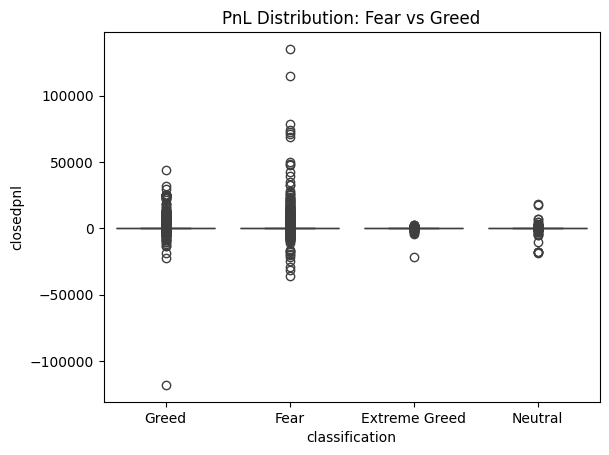

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='closedpnl', data=merged)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()